In [61]:
import pandas as pd
from narwhals.stable.v2 import exclude

pd.options.display.max_columns = None
df = pd.read_csv("data/student_placement_prediction_dataset_2026.csv")

In [62]:
df.head(10)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,184,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,539,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,568,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,550,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,833,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
5,6,22,Male,7.44,CSE,Tier 2,1,5,1,49.758865,45.252593,51.881728,69.984592,3,8,77,66.138578,82.038139,0,54.150818,69.210022,No,9.1,3.4,Placed,11.78
6,7,22,Male,7.54,CSE,Tier 3,0,2,2,68.816160,63.787196,79.969910,76.546475,0,2,154,56.207496,72.267945,1,79.323137,26.179746,No,8.9,3.1,Not Placed,0.00
7,8,24,Female,6.86,Civil,Tier 3,3,4,2,87.471971,56.962395,58.138781,66.579454,2,8,98,89.189601,79.128528,1,23.394036,36.903695,Yes,8.8,1.6,Not Placed,0.00
8,9,19,Male,8.52,Mechanical,Tier 2,2,5,0,100.000000,93.987115,75.165144,87.737986,0,7,269,64.035703,89.884948,0,68.598878,42.647145,No,8.5,4.2,Placed,16.33
9,10,20,Female,8.07,Civil,Tier 2,2,2,2,93.421972,71.379374,57.215196,58.628985,0,6,747,72.217117,88.901107,0,86.199176,1.371853,No,5.9,4.5,Placed,16.17


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

student_id — ID студента

age — Возраст

gender — Пол

cgpa — CGPA (средний балл)

branch — Специальность / Направление

college_tier — Уровень колледжа (Tier)

internships_count — Количество стажировок

projects_count — Количество проектов

certifications_count — Количество сертификатов

coding_skill_score — Уровень навыков программирования

aptitude_score — Оценка способностей (aptitude test)

communication_skill_score — Навыки коммуникации

logical_reasoning_score — Логическое мышление

hackathons_participated — Участие в хакатонах

github_repos — Репозитории на GitHub

linkedin_connections — Связи на LinkedIn

mock_interview_score — Оценка за пробное собеседование

attendance_percentage — Процент посещаемости

backlogs — Количество долгов / пересдач

extracurricular_score — Внеучебная активность

leadership_score — Лидерские качества

volunteer_experience — Волонтёрский опыт

sleep_hours — Часы сна в сутки

study_hours_per_day — Часы учёбы в день

placement_status — Статус трудоустройства

salary_package_lpa — Зарплата (в LPA — lakhs per annum)

*Для классификации:* placement_status - трудоустроился или нет

*Для регрессии:* salary_package_lpa - зарплата

In [64]:
# КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']

le = LabelEncoder()

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

print(df[['placement_status', 'placement_status_encoded']].head())

  placement_status  placement_status_encoded
0       Not Placed                         0
1       Not Placed                         0
2           Placed                         1
3       Not Placed                         0
4           Placed                         1


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   student_id                    100000 non-null  int64  
 1   age                           100000 non-null  int64  
 2   gender                        100000 non-null  str    
 3   cgpa                          100000 non-null  float64
 4   branch                        100000 non-null  str    
 5   college_tier                  100000 non-null  str    
 6   internships_count             100000 non-null  int64  
 7   projects_count                100000 non-null  int64  
 8   certifications_count          100000 non-null  int64  
 9   coding_skill_score            100000 non-null  float64
 10  aptitude_score                100000 non-null  float64
 11  communication_skill_score     100000 non-null  float64
 12  logical_reasoning_score       100000 non-null  float64
 

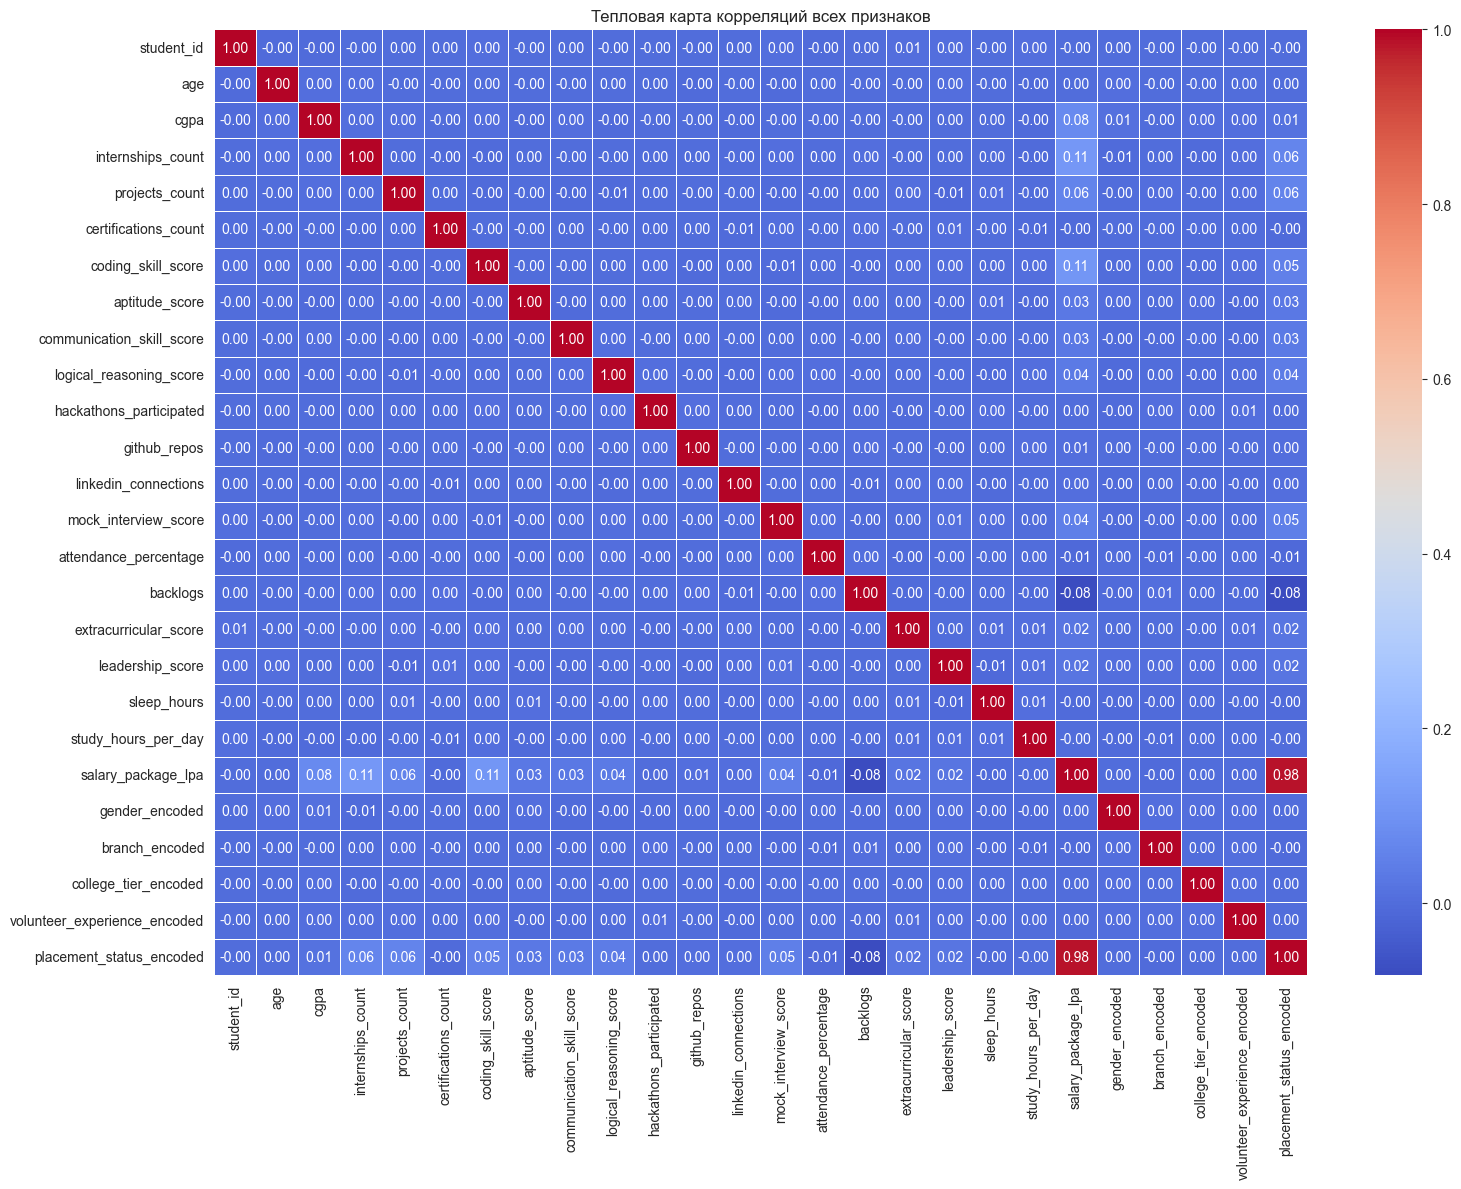

In [66]:
# КОРРЕЛЯЦИОННАЯ МАТРИЦА И ТЕПЛОВАЯ КАРТА
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int32', 'int64', 'float64']).copy()

plt.figure(figsize=(16, 12))
corr_matrix = numeric_df.corr() # можно добавить method='spearman'

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций всех признаков')
plt.tight_layout()
plt.show()

Самые заметные корреляции с placement_status_encoded (трудоустройство):

- salary_package_lpa → +0.98
- (это логично: если человек устроился — у него есть зарплата, если нет — 0)
- internships_count → +0.05 - Количество стажировок
- projects_count → +0.06 - Количество проектов
- coding_skill_score → +0.05 - Навыки программирования
- mock_interview_score → +0.04 - Результаты мок-интервью
- cgpa → +0.06 - Средний балл за весь период обучения
- aptitude_score → +0.03 - Средний рейтинг за тест
- backlogs → -0.08 (чем больше долгов — тем хуже шансы на трудоустройство)


Корреляции с salary_package_lpa (зарплата):

- internships_count → +0.11 - Количества стажировок
- coding_skill_score → +0.11 - Навыки программирования
- cgpa → +0.08 - Средний балл за весь период обучения
- projects_count → +0.06 - Количества проектов
- mock_interview_score → +0.04 - Результаты интервью


Корреляция входных признаков с трудоустройством (по убыванию):
internships_count               0.063489
projects_count                  0.060964
coding_skill_score              0.050773
mock_interview_score            0.046058
logical_reasoning_score         0.036332
communication_skill_score       0.032242
aptitude_score                  0.031690
leadership_score                0.022170
extracurricular_score           0.020100
cgpa                            0.012067
github_repos                    0.004807
linkedin_connections            0.003223
college_tier_encoded            0.002005
gender_encoded                  0.001244
volunteer_experience_encoded    0.001240
hackathons_participated         0.001236
age                             0.000858
student_id                     -0.000821
study_hours_per_day            -0.001426
certifications_count           -0.003806
branch_encoded                 -0.004320
sleep_hours                    -0.004692
attendance_percentage          -0.0

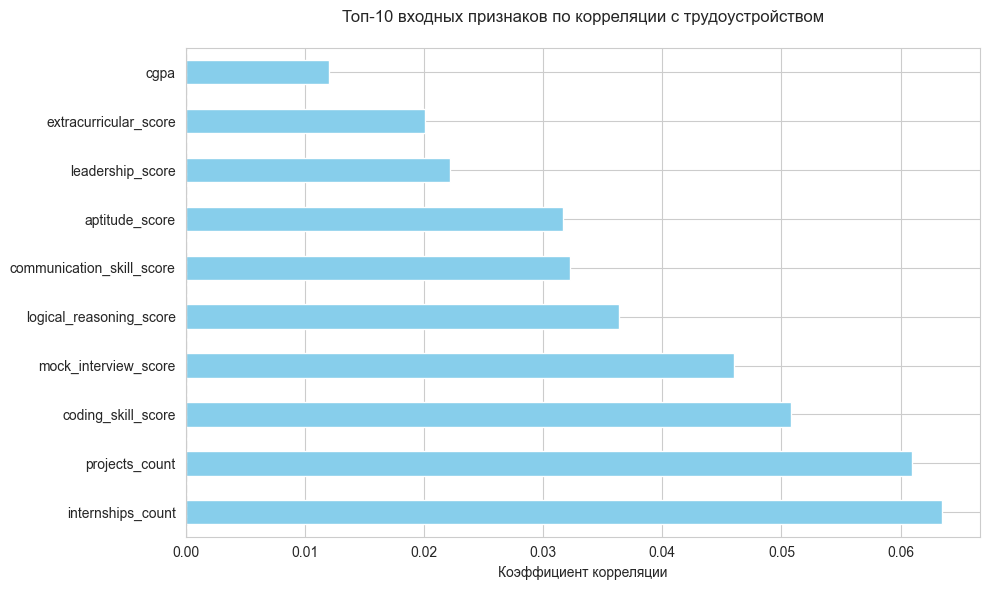

In [67]:
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ТРУДОУСТРОЙСТВОМ

target = 'placement_status_encoded'

exclude_cols = ['placement_status_encoded', 'salary_package_lpa']

features_df = numeric_df.drop(columns=exclude_cols, errors='ignore')
correlations = features_df.corrwith(numeric_df[target]).sort_values(ascending=False)

print("Корреляция входных признаков с трудоустройством (по убыванию):")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 входных признаков по корреляции с трудоустройством\n')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

Корреляция входных признаков с зарплатой (по убыванию):
internships_count               0.063489
projects_count                  0.060964
coding_skill_score              0.050773
mock_interview_score            0.046058
logical_reasoning_score         0.036332
communication_skill_score       0.032242
aptitude_score                  0.031690
leadership_score                0.022170
extracurricular_score           0.020100
cgpa                            0.012067
github_repos                    0.004807
linkedin_connections            0.003223
college_tier_encoded            0.002005
gender_encoded                  0.001244
volunteer_experience_encoded    0.001240
hackathons_participated         0.001236
age                             0.000858
student_id                     -0.000821
study_hours_per_day            -0.001426
certifications_count           -0.003806
branch_encoded                 -0.004320
sleep_hours                    -0.004692
attendance_percentage          -0.008350
b

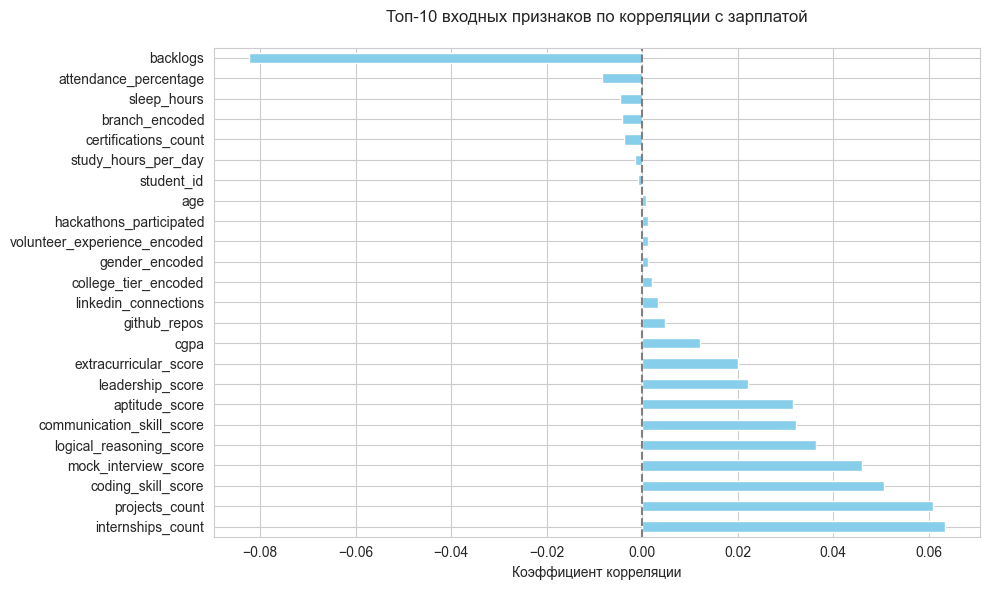

In [68]:
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЗАРПЛАТОЙ

target = 'placement_status_encoded'

exclude_cols = ['salary_package_lpa', 'salary_package_lpa', 'placement_status_encoded']

features_df = numeric_df.drop(columns=exclude_cols, errors='ignore')
correlations = features_df.corrwith(numeric_df[target]).sort_values(ascending=False)

print("Корреляция входных признаков с зарплатой (по убыванию):")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.head(50).plot(kind='barh', color='skyblue')
plt.title('Топ-10 входных признаков по корреляции с зарплатой\n')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

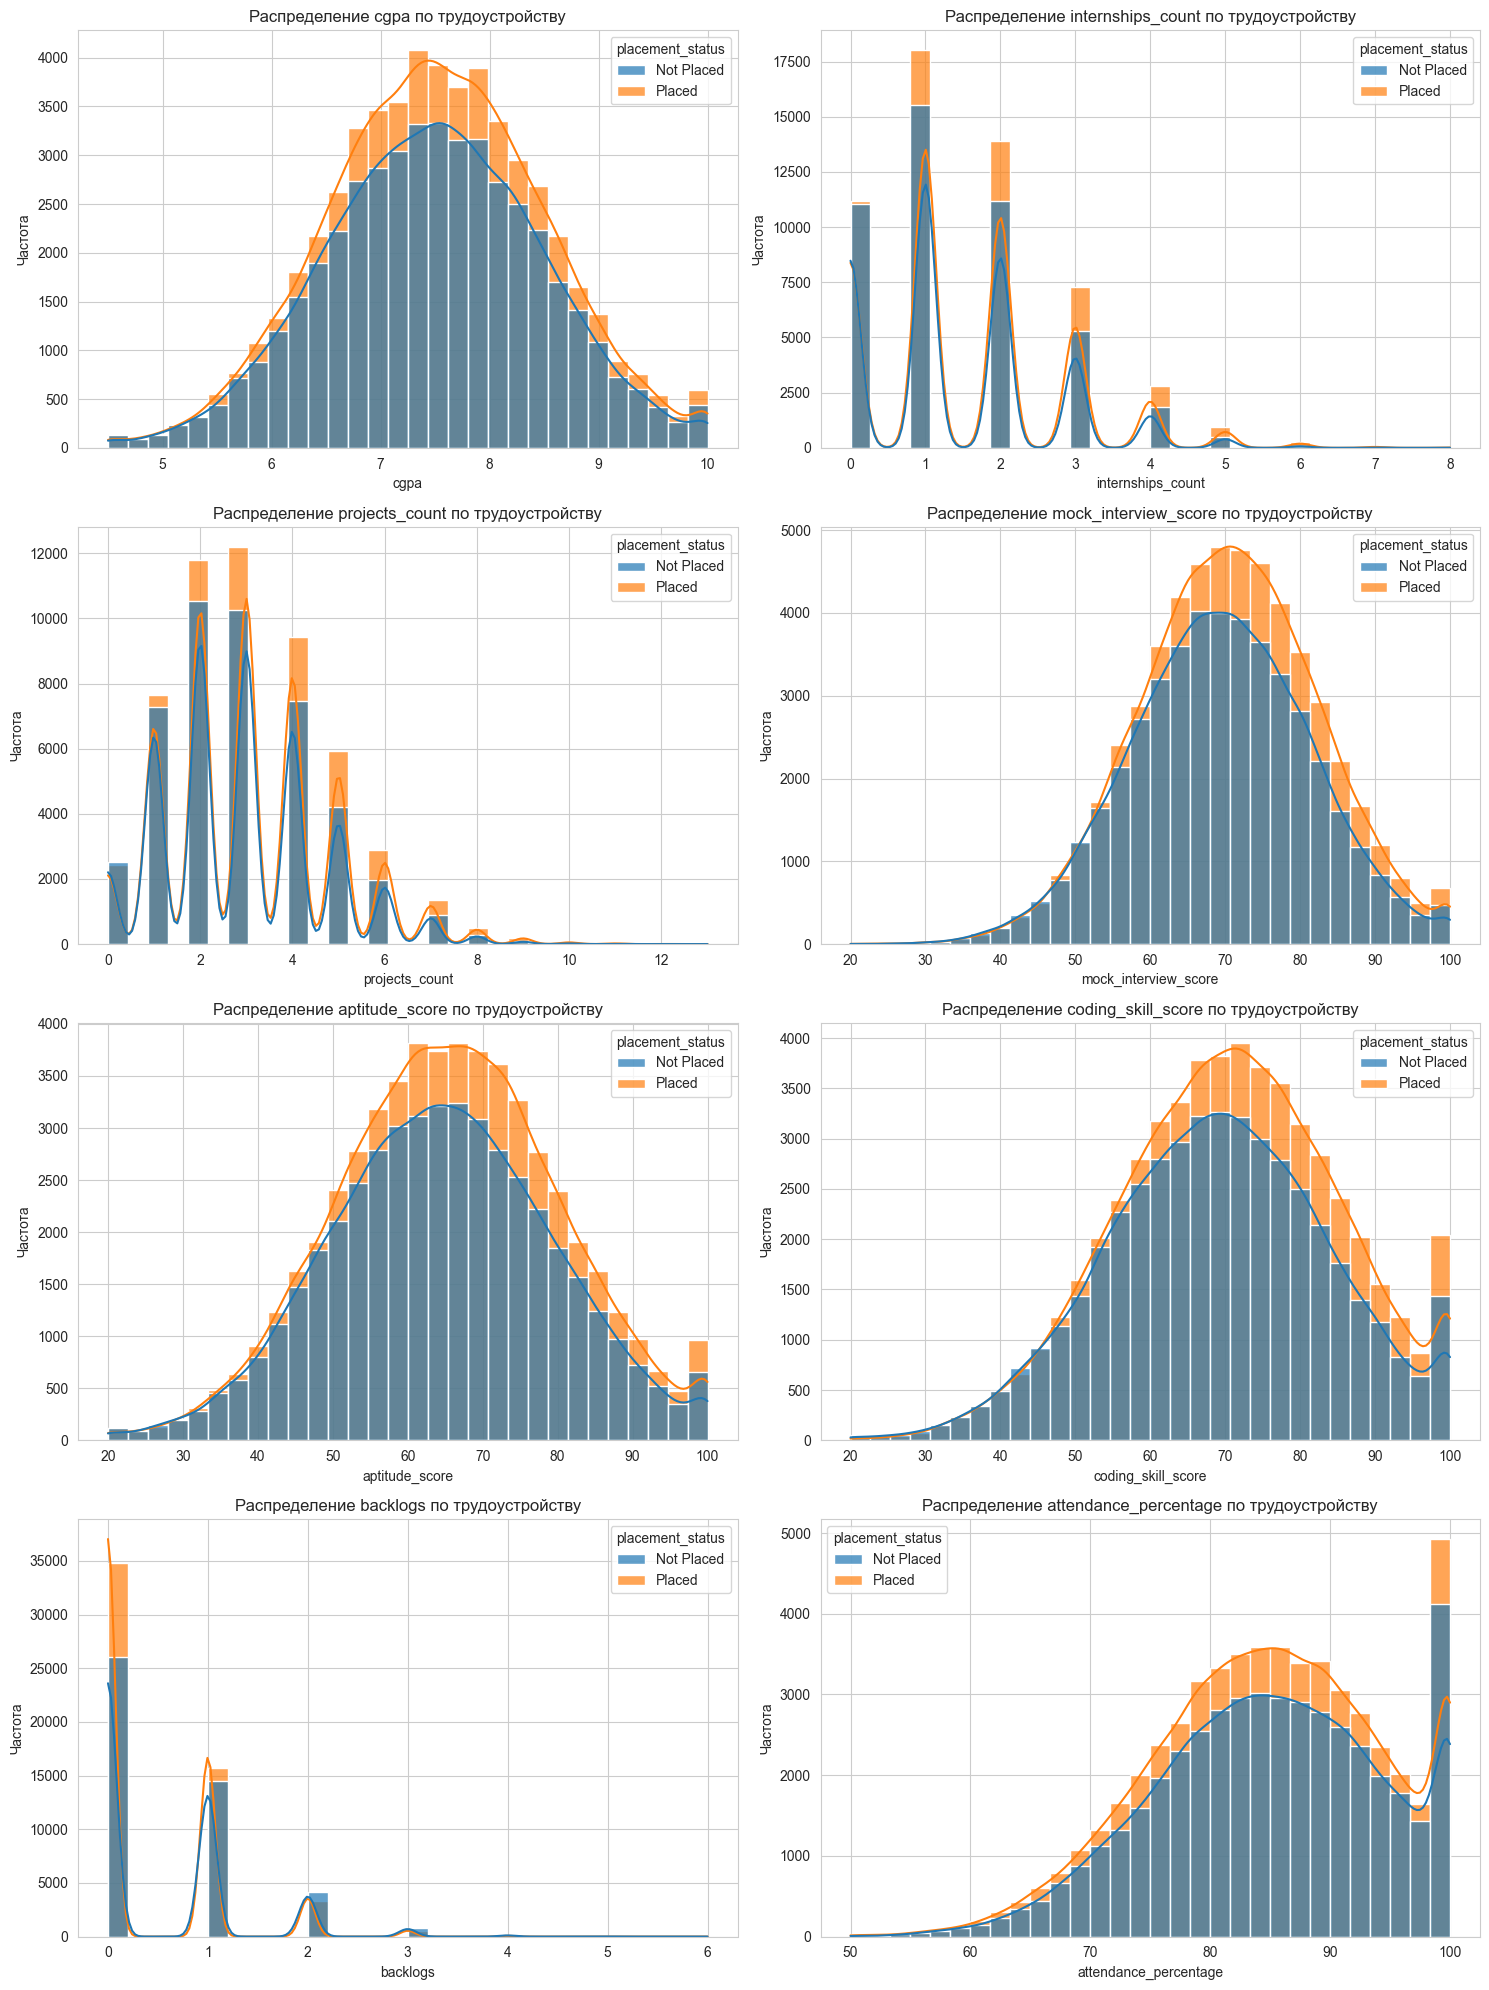

In [69]:
# ГРАФИКИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ

important_features = ['cgpa', 'internships_count', 'projects_count', 'mock_interview_score',
                      'aptitude_score', 'coding_skill_score', 'backlogs', 'attendance_percentage']

plt.figure(figsize=(15, 20))

for i, feature in enumerate(important_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(data=df, x=feature, hue='placement_status', kde=True, bins=30, alpha=0.7)
    plt.title(f'Распределение {feature} по трудоустройству')
    plt.xlabel(feature)
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

Трудоустраиваются те, кто хорошо учится, делает проекты, а также **БОЛЬШЕ** ходит по собесам и лучше кодит

4. Определить целевые векторы для решения на выбранном датасете задачи регрессионного анализа. Произвести предварительную подготовку данных для обучения, включающую:

* удаление информационных выбросов;
* исключение противоречий;
* исключение некорректных значений;
* обработку пропусков.

Основным вектором для задачи регрессии будет зарплата трудоустроенных студентов

In [70]:
df_placed = df[df['placement_status'] == 'Placed'].copy()
y_reg = df_placed['salary_package_lpa']

print("Размер выборки для регрессии:", df_placed.shape)
print("Средняя зарплата среди Placed: {:.2f} LPA".format(y_reg.mean()))
print("Медианная зарплата среди Placed: {:.2f} LPA".format(y_reg.median()))

Размер выборки для регрессии: (54459, 31)
Средняя зарплата среди Placed: 13.32 LPA
Медианная зарплата среди Placed: 13.30 LPA


Предобработка

In [71]:
print("Пропусков:", df.isna().sum().sum())

df_clean = df.copy()

# Ограничиваем диапазоны
df_clean = df_clean[
    (df_clean['cgpa'].between(4.0, 10.0)) &
    (df_clean['age'].between(17, 25)) &
    (df_clean['attendance_percentage'].between(30, 100)) &
    (df_clean['backlogs'] <= 8)
]

score_cols = [
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'mock_interview_score'
]
for col in score_cols:
    df_clean[col] = df_clean[col].clip(0, 100)

print("Размер после фильтрации некорректных значений:", df_clean.shape)

Пропусков: 0
Размер после фильтрации некорректных значений: (100000, 31)


In [72]:
# Базовые статистики по числовым признакам
print("\nЧисловые признаки:")
print(df.describe(include='number').T)


Числовые признаки:
                                 count          mean           std   min  \
student_id                    100000.0  50000.500000  28867.657797   1.0   
age                           100000.0     21.005740      1.999562  18.0   
cgpa                          100000.0      7.496890      0.992834   4.5   
internships_count             100000.0      1.502230      1.225280   0.0   
projects_count                100000.0      3.001860      1.731764   0.0   
certifications_count          100000.0      2.005150      1.416553   0.0   
coding_skill_score            100000.0     69.825326     14.694618  20.0   
aptitude_score                100000.0     64.988108     14.844093  20.0   
communication_skill_score     100000.0     67.960744     13.846636  20.0   
logical_reasoning_score       100000.0     65.931696     14.826790  20.0   
hackathons_participated       100000.0      1.000690      0.997908   0.0   
github_repos                  100000.0      4.005160      2.004897  

In [73]:
# Удаляем строки с пропусками
df_clean = df.dropna().copy()
print(f"Размер до удаления NaN: {df.shape}, после: {df_clean.shape}")

Размер до удаления NaN: (100000, 31), после: (100000, 31)


Удаление информационных выбросов

In [74]:
df_reg = df_clean[df_clean['placement_status'] == 'Placed'].copy()


lower = df_reg['salary_package_lpa'].quantile(0.005)
upper = df_reg['salary_package_lpa'].quantile(0.995)

print(f"Удаляем зарплаты < {lower:.2f} и > {upper:.2f} LPA")

df_reg = df_reg[
    df_reg['salary_package_lpa'].between(lower, upper)
]

print("Размер после удаления выбросов по зарплате:", df_reg.shape)

Удаляем зарплаты < 9.32 и > 17.39 LPA
Размер после удаления выбросов по зарплате: (53917, 31)


Работа с противоречиями

In [75]:
# не может быть трудостроуен с зарплатой = 0
contradict = df[(df['placement_status'] == 'Placed') & (df['salary_package_lpa'] == 0)]
print("Трудостроуен с зарплатой = 0:", len(contradict))

# Не может быть устроенным, но с зарплатой > 0
contradict2 = df[(df['placement_status'] == 'Not Placed') & (df['salary_package_lpa'] > 0)]
print("Устроен, но зарплата > 0:", len(contradict2))


df_clean = df_clean[
    ~((df_clean['placement_status'] == 'Placed') & (df_clean['salary_package_lpa'] == 0)) &
    ~((df_clean['placement_status'] == 'Not Placed') & (df_clean['salary_package_lpa'] > 0))
]

Трудостроуен с зарплатой = 0: 0
Устроен, но зарплата > 0: 0


5.	Определить целевые векторы для решения на выбранном датасете задачи регрессионного анализа. Произвести предварительную подготовку  данных для обучения, включающую:
* поиск и замену неявных дубликатов;
* нормализацию данных датасета.
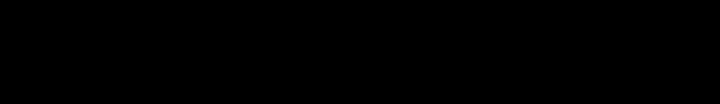

In [76]:
# Проверка полных дубликатов

duplicates_full = df.duplicated().sum()
print(f"Полных одинаковых строк: {duplicates_full}")

if duplicates_full > 0:
    df = df.drop_duplicates()
    print("Удалено полных дубликатов строк")

Полных одинаковых строк: 0


In [77]:
# Проверка дубликатов с одинаковыми базовыми значениями

key_cols = ['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier']

dups_key = df.duplicated(subset=key_cols, keep=False)
print(f"Записей, которые дублируются по ключевым полям: {dups_key.sum()}")

if dups_key.sum() > 0:
    print("Примеры дубликатов:")
    print(df[dups_key].sort_values(key_cols).head(6))

    # Самый простой и безопасный вариант — оставить первую запись
    df = df.drop_duplicates(subset=key_cols, keep='first')
    print(f"После удаления: {df.shape}")

Записей, которые дублируются по ключевым полям: 0


In [78]:
# Проверка неявных дубликатов в категориях (опечатки, регистр)

cat_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']

for col in cat_cols:
    unique = df[col].astype(str).str.lower().str.strip().value_counts()
    print(f"\n{col} (приведено к нижнему регистру и очищено):")
    print(unique)


gender (приведено к нижнему регистру и очищено):
gender
male      60028
female    39972
Name: count, dtype: int64

branch (приведено к нижнему регистру и очищено):
branch
cse           34818
it            19999
ece           14908
eee           10177
mechanical    10077
civil         10021
Name: count, dtype: int64

college_tier (приведено к нижнему регистру и очищено):
college_tier
tier 2    49955
tier 3    29884
tier 1    20161
Name: count, dtype: int64

volunteer_experience (приведено к нижнему регистру и очищено):
volunteer_experience
no     59963
yes    40037
Name: count, dtype: int64

placement_status (приведено к нижнему регистру и очищено):
placement_status
placed        54459
not placed    45541
Name: count, dtype: int64


Нормализация

In [79]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# числовые признаки, которые будем нормализовать
# исключаем: student_id, целевые переменные
features_to_scale = [
    'age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count',
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'hackathons_participated', 'github_repos',
    'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
    'backlogs', 'extracurricular_score', 'leadership_score',
    'sleep_hours', 'study_hours_per_day'
]

# Целевой вектор для регресии
df_reg = df[df['placement_status'] == 'Placed'].copy()

# MinMaxScaler [0,1]
# scaler_mm = MinMaxScaler()
# df_reg[features_to_scale] = scaler_mm.fit_transform(df_reg[features_to_scale])

# StandardScaler (среднее 0, std 1)
scaler_ss = StandardScaler()
df_reg[features_to_scale] = scaler_ss.fit_transform(df_reg[features_to_scale])

print("После нормализации (первые 3 строки):")
print(df_reg[features_to_scale].head(3))



После нормализации (первые 3 строки):
        age      cgpa  internships_count  projects_count  \
2  0.497004  1.100451          -1.253275       -1.190599   
4 -0.504322  0.929159          -0.456719        0.511550   
5  0.497004 -0.068362          -0.456719        1.078933   

   certifications_count  coding_skill_score  aptitude_score  \
2             -0.705729           -1.458993       -1.129553   
4              0.705418           -0.375447       -0.279248   
5             -0.705729           -1.419206       -1.359120   

   communication_skill_score  logical_reasoning_score  \
2                   1.712999                 0.960440   
4                   1.485770                -0.695020   
5                  -1.189872                 0.241162   

   hackathons_participated  github_repos  linkedin_connections  \
2                -1.000314     -1.002632              0.155077   
4                -0.001815     -0.006957              1.119073   
5                 1.995183      1.984394 

In [80]:
print("После нормализации — min и max по всем признакам:")
print(df_reg[features_to_scale].min().round(4))
print("\n")
print(df_reg[features_to_scale].max().round(4))

После нормализации — min и max по всем признакам:
age                         -1.5056
cgpa                        -3.0307
internships_count           -1.2533
projects_count              -1.7580
certifications_count        -1.4113
coding_skill_score          -3.4547
aptitude_score              -3.0611
communication_skill_score   -3.4907
logical_reasoning_score     -3.1446
hackathons_participated     -1.0003
github_repos                -1.9983
linkedin_connections        -1.7293
mock_interview_score        -4.2364
attendance_percentage       -3.6699
backlogs                    -0.6682
extracurricular_score       -3.0899
leadership_score            -2.7980
sleep_hours                 -2.7051
study_hours_per_day         -2.0521
dtype: float64


age                          1.4983
cgpa                         2.5111
internships_count            5.1192
projects_count               5.6180
certifications_count         6.3500
coding_skill_score           2.0173
aptitude_score               2.33

7. Оптимизировать пространнство признаков. Методом главных компонент, РСА
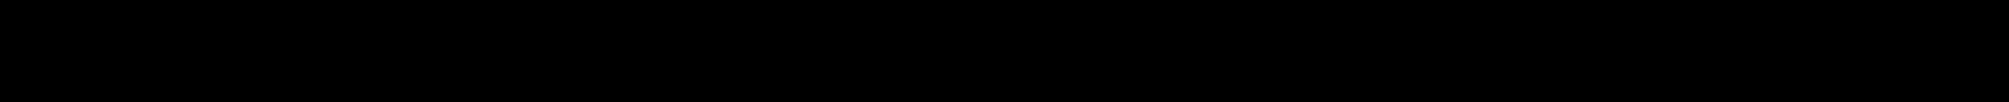

In [81]:
feature_cols = [
    'age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count',
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'hackathons_participated', 'github_repos',
    'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
    'backlogs', 'extracurricular_score', 'leadership_score',
    'sleep_hours', 'study_hours_per_day'
]

# Целевая переменная для регрессии
y_reg = df_reg['salary_package_lpa']

# Матрица признаков X
X_reg = df_reg[feature_cols]

print(f"Размер матрицы признаков X: {X_reg.shape}")
print(f"Размер целевой переменной y: {y_reg.shape}")

Размер матрицы признаков X: (54459, 19)
Размер целевой переменной y: (54459,)


In [82]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (43567, 19)
Размер тестовой выборки: (10892, 19)


In [83]:
from sklearn.decomposition import PCA


pca = PCA()
pca.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [84]:
import numpy as np

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

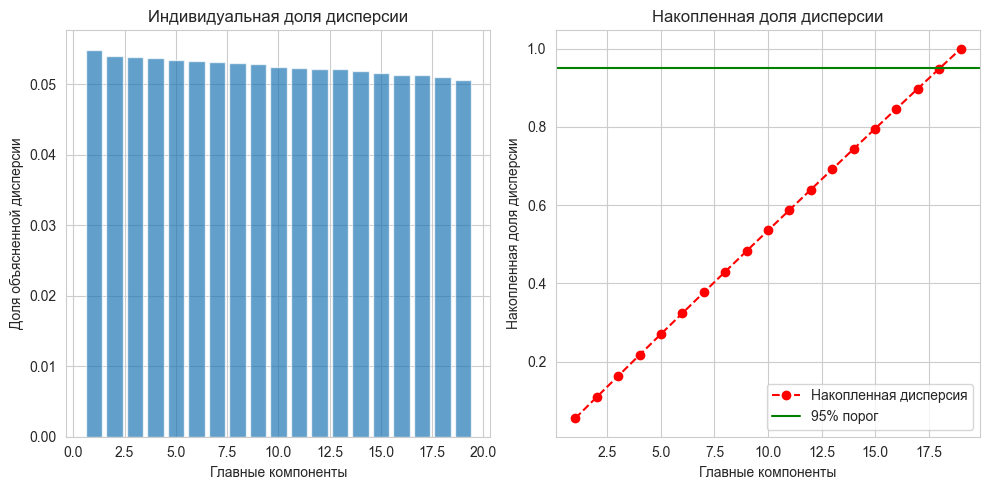

In [85]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Индивидуальная дисперсия')
plt.xlabel('Главные компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Индивидуальная доля дисперсии')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='r', label='Накопленная дисперсия')
plt.xlabel('Главные компоненты')
plt.ylabel('Накопленная доля дисперсии')
plt.title('Накопленная доля дисперсии')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% порог')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
# Найдем количество компонент для 95% дисперсии
n_components_for_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Количество компонент для сохранения 95% дисперсии: {n_components_for_95}")

Количество компонент для сохранения 95% дисперсии: 19


In [87]:
# Применим PCA с этим количеством компонент
pca_final = PCA(n_components=n_components_for_95)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test) # ВАЖНО: используем transform, а не fit_transform

print(f"Размер обучающей выборки после PCA: {X_train_pca.shape}")
print(f"Размер тестовой выборки после PCA: {X_test_pca.shape}")

Размер обучающей выборки после PCA: (43567, 19)
Размер тестовой выборки после PCA: (10892, 19)


8. Обучение ML

In [88]:
from sklearn.metrics import mean_squared_error, r2_score

# Функция для оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"\n--- {model_name} ---")
    print(f"RMSE на обучении: {rmse_train:.4f}")
    print(f"RMSE на тесте: {rmse_test:.4f}")
    print(f"R2 на обучении: {r2_train:.4f}")
    print(f"R2 на тесте: {r2_test:.4f}")
    return rmse_test, r2_test

In [89]:
from sklearn.neighbors import KNeighborsRegressor


# K-ближайших соседей (KNN)
k_values = [3, 5, 7, 9, 11]
knn_results = []

print("\n" + "="*50)
print("ОБУЧЕНИЕ KNN")
print("="*50)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    rmse, r2 = evaluate_model(knn, X_train_pca, X_test_pca, y_train, y_test, f"KNN (k={k})")
    knn_results.append({'k': k, 'rmse': rmse, 'r2': r2})


ОБУЧЕНИЕ KNN

--- KNN (k=3) ---
RMSE на обучении: 0.0000
RMSE на тесте: 1.2836
R2 на обучении: 1.0000
R2 на тесте: 0.3496

--- KNN (k=5) ---
RMSE на обучении: 0.0000
RMSE на тесте: 1.2131
R2 на обучении: 1.0000
R2 на тесте: 0.4191

--- KNN (k=7) ---
RMSE на обучении: 0.0000
RMSE на тесте: 1.1859
R2 на обучении: 1.0000
R2 на тесте: 0.4449

--- KNN (k=9) ---
RMSE на обучении: 0.0000
RMSE на тесте: 1.1732
R2 на обучении: 1.0000
R2 на тесте: 0.4567

--- KNN (k=11) ---
RMSE на обучении: 0.0000
RMSE на тесте: 1.1613
R2 на обучении: 1.0000
R2 на тесте: 0.4676


In [90]:
from sklearn.ensemble import RandomForestRegressor


# Случайный лес (Random Forest)

n_estimators_list = [50, 100, 150]
max_depth_list = [10, 20, None]

rf_results = []

print("\n" + "="*50)
print("ОБУЧЕНИЕ RANDOM FOREST")
print("="*50)

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        rf = RandomForestRegressor(n_estimators=n_est, max_depth=max_d, random_state=42, n_jobs=-1)
        model_name = f"RF (n_est={n_est}, max_depth={max_d})"
        rmse, r2 = evaluate_model(rf, X_train_pca, X_test_pca, y_train, y_test, model_name)
        rf_results.append({'n_estimators': n_est, 'max_depth': max_d, 'rmse': rmse, 'r2': r2})


ОБУЧЕНИЕ RANDOM FOREST

--- RF (n_est=50, max_depth=10) ---
RMSE на обучении: 0.9819
RMSE на тесте: 1.1673
R2 на обучении: 0.6199
R2 на тесте: 0.4621

--- RF (n_est=50, max_depth=20) ---
RMSE на обучении: 0.4335
RMSE на тесте: 1.1107
R2 на обучении: 0.9259
R2 на тесте: 0.5130

--- RF (n_est=50, max_depth=None) ---
RMSE на обучении: 0.4206
RMSE на тесте: 1.1116
R2 на обучении: 0.9303
R2 на тесте: 0.5122

--- RF (n_est=100, max_depth=10) ---
RMSE на обучении: 0.9797
RMSE на тесте: 1.1627
R2 на обучении: 0.6215
R2 на тесте: 0.4663

--- RF (n_est=100, max_depth=20) ---
RMSE на обучении: 0.4244
RMSE на тесте: 1.1047
R2 на обучении: 0.9290
R2 на тесте: 0.5183

--- RF (n_est=100, max_depth=None) ---
RMSE на обучении: 0.4109
RMSE на тесте: 1.1045
R2 на обучении: 0.9334
R2 на тесте: 0.5185

--- RF (n_est=150, max_depth=10) ---
RMSE на обучении: 0.9786
RMSE на тесте: 1.1617
R2 на обучении: 0.6224
R2 на тесте: 0.4673

--- RF (n_est=150, max_depth=20) ---
RMSE на обучении: 0.4204
RMSE на тесте: 1

In [91]:
# Соберем все результаты в один DataFrame для удобства
import pandas as pd

# KNN DataFrame
knn_df = pd.DataFrame(knn_results)
knn_df['model'] = knn_df['k'].apply(lambda x: f'KNN (k={x})')
knn_df = knn_df[['model', 'rmse', 'r2']]

# RF DataFrame
rf_df = pd.DataFrame(rf_results)
rf_df['model'] = rf_df.apply(lambda row: f"RF (n_est={row['n_estimators']}, max_depth={row['max_depth']})", axis=1)
rf_df = rf_df[['model', 'rmse', 'r2']]

# Объединяем
comparison_df = pd.concat([knn_df, rf_df], ignore_index=True)
comparison_df = comparison_df.sort_values(by='rmse')

print("\nЛучшие модели по RMSE на тесте:")
print(comparison_df.head(10).to_string(index=False))


Лучшие модели по RMSE на тесте:
                           model     rmse       r2
 RF (n_est=150.0, max_depth=nan) 1.101786 0.520807
RF (n_est=150.0, max_depth=20.0) 1.101983 0.520636
 RF (n_est=100.0, max_depth=nan) 1.104454 0.518483
RF (n_est=100.0, max_depth=20.0) 1.104685 0.518281
 RF (n_est=50.0, max_depth=20.0) 1.110697 0.513024
  RF (n_est=50.0, max_depth=nan) 1.111619 0.512216
                      KNN (k=11) 1.161336 0.467608
RF (n_est=150.0, max_depth=10.0) 1.161699 0.467275
RF (n_est=100.0, max_depth=10.0) 1.162708 0.466349
 RF (n_est=50.0, max_depth=10.0) 1.167277 0.462147


Задача классификации

In [92]:
y_clf = df['placement_status_encoded']

features_for_clf = [col for col in df.columns if col not in
                    ['placement_status', 'placement_status_encoded',
                     'salary_package_lpa', 'student_id', 'gender', 'branch',
                     'college_tier', 'volunteer_experience']]
X_clf = df[features_for_clf]

print("Размер матрицы признаков для классификации X:", X_clf.shape)
print("Размер целевой переменной y:", y_clf.shape)
print("Распределение классов:\n", y_clf.value_counts())

Размер матрицы признаков для классификации X: (100000, 23)
Размер целевой переменной y: (100000,)
Распределение классов:
 placement_status_encoded
1    54459
0    45541
Name: count, dtype: int64


In [93]:
print("Исходное распределение классов:")
print(y_clf.value_counts(normalize=True))

Исходное распределение классов:
placement_status_encoded
1    0.54459
0    0.45541
Name: proportion, dtype: float64


In [94]:
from sklearn.preprocessing import StandardScaler

features_to_scale_clf = [col for col in features_for_clf if col not in
                         ['gender_encoded', 'branch_encoded', 'college_tier_encoded',
                          'volunteer_experience_encoded']]


df_clf_prepared = df[features_for_clf].copy()

# StandardScaler
scaler_clf = StandardScaler()
df_clf_prepared[features_to_scale_clf] = scaler_clf.fit_transform(df_clf_prepared[features_to_scale_clf])

print("После нормализации (первые 3 строки):")
print(df_clf_prepared.head(3))

После нормализации (первые 3 строки):
        age      cgpa  internships_count  projects_count  \
0  1.497466  0.033349           2.038541        1.731272   
1 -0.002871  0.426166          -0.409892       -0.001074   
2  0.497241  1.111077          -1.226037       -1.155972   

   certifications_count  coding_skill_score  aptitude_score  \
0             -0.709578            2.001644        1.126354   
1              2.820134            0.758159       -0.126070   
2             -0.709578           -1.405157       -1.100063   

   communication_skill_score  logical_reasoning_score  \
0                  -0.740514                -0.462788   
1                  -0.632912                 0.879812   
2                   1.743692                 0.989540   

   hackathons_participated  github_repos  linkedin_connections  \
0                 3.005614     -1.498917             -1.238432   
1                -1.002793     -1.000136              0.052514   
2                -1.002793     -1.000136 

In [95]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    df_clf_prepared, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Размер обучающей выборки: {X_train_clf.shape}")
print(f"Размер тестовой выборки: {X_test_clf.shape}")
print(f"Распределение классов в обучающей выборке:\n{y_train_clf.value_counts(normalize=True)}")

Размер обучающей выборки: (80000, 23)
Размер тестовой выборки: (20000, 23)
Распределение классов в обучающей выборке:
placement_status_encoded
1    0.544588
0    0.455412
Name: proportion, dtype: float64


In [96]:
from sklearn.decomposition import PCA

pca_clf = PCA()
pca_clf.fit(X_train_clf)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

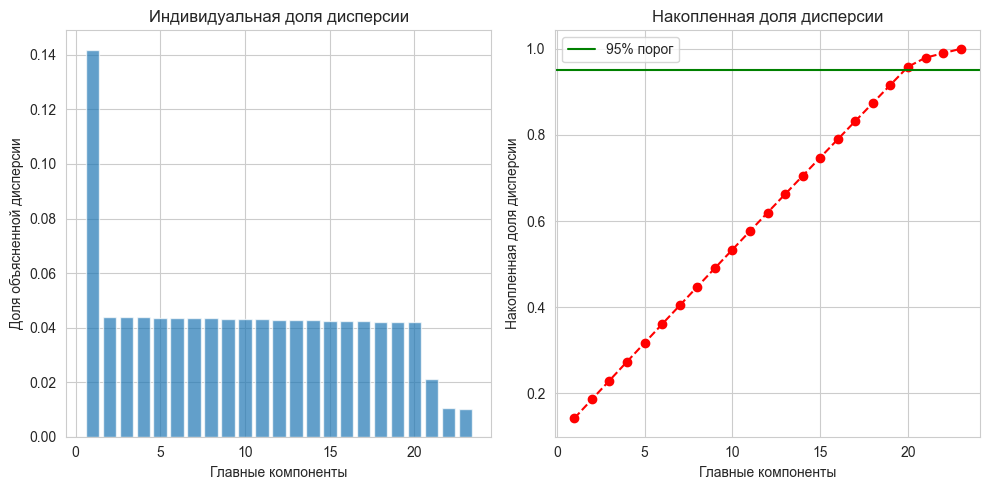

In [97]:
import numpy as np
import matplotlib.pyplot as plt

explained_variance_clf = pca_clf.explained_variance_ratio_
cumulative_variance_clf = np.cumsum(explained_variance_clf)



plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_clf) + 1), explained_variance_clf, alpha=0.7)
plt.xlabel('Главные компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Индивидуальная доля дисперсии')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance_clf) + 1), cumulative_variance_clf, marker='o', linestyle='--', color='r')
plt.xlabel('Главные компоненты')
plt.ylabel('Накопленная доля дисперсии')
plt.title('Накопленная доля дисперсии')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% порог')
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
n_components_for_95_clf = np.argmax(cumulative_variance_clf >= 0.95) + 1
print(f"Количество компонент для сохранения 95% дисперсии: {n_components_for_95_clf}")

Количество компонент для сохранения 95% дисперсии: 20


In [99]:
pca_final_clf = PCA(n_components=n_components_for_95_clf)
X_train_pca_clf = pca_final_clf.fit_transform(X_train_clf)
X_test_pca_clf = pca_final_clf.transform(X_test_clf)

print(f"Размер обучающей выборки после PCA: {X_train_pca_clf.shape}")
print(f"Размер тестовой выборки после PCA: {X_test_pca_clf.shape}")

Размер обучающей выборки после PCA: (80000, 20)
Размер тестовой выборки после PCA: (20000, 20)


In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import pandas as pd

def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name="Classifier"):
    """Обучает модель и выводит метрики классификации."""
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n--- {model_name} ---")
    print("Метрики на тестовой выборке:")
    print(f"  Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
    print(f"  F1-score:  {f1_score(y_test, y_pred_test):.4f}")
    if y_proba_test is not None:
        print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}")

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test),
        'recall': recall_score(y_test, y_pred_test),
        'f1': f1_score(y_test, y_pred_test),
        'roc_auc': roc_auc_score(y_test, y_proba_test) if y_proba_test is not None else None
    }

In [101]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

results = []

# 1. KNN
k_values = [3, 5, 7, 9, 11]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    res = evaluate_classifier(knn, X_train_pca_clf, X_test_pca_clf, y_train_clf, y_test_clf, f"KNN (k={k})")
    results.append(res)

# 2. Random Forest
rf_params = [
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 20}
]
for params in rf_params:
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model_name = f"RF (n_est={params['n_estimators']}, max_depth={params['max_depth']})"
    res = evaluate_classifier(rf, X_train_pca_clf, X_test_pca_clf, y_train_clf, y_test_clf, model_name)
    results.append(res)

# 3. Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
res = evaluate_classifier(lr, X_train_pca_clf, X_test_pca_clf, y_train_clf, y_test_clf, "Logistic Regression")
results.append(res)


--- KNN (k=3) ---
Метрики на тестовой выборке:
  Accuracy:  0.5162
  Precision: 0.5539
  Recall:    0.5743
  F1-score:  0.5639
  ROC-AUC:   0.5164

--- KNN (k=5) ---
Метрики на тестовой выборке:
  Accuracy:  0.5182
  Precision: 0.5542
  Recall:    0.5895
  F1-score:  0.5713
  ROC-AUC:   0.5189

--- KNN (k=7) ---
Метрики на тестовой выборке:
  Accuracy:  0.5255
  Precision: 0.5592
  Recall:    0.6082
  F1-score:  0.5827
  ROC-AUC:   0.5230

--- KNN (k=9) ---
Метрики на тестовой выборке:
  Accuracy:  0.5245
  Precision: 0.5572
  Recall:    0.6186
  F1-score:  0.5863
  ROC-AUC:   0.5235

--- KNN (k=11) ---
Метрики на тестовой выборке:
  Accuracy:  0.5255
  Precision: 0.5569
  Recall:    0.6295
  F1-score:  0.5910
  ROC-AUC:   0.5270

--- RF (n_est=100, max_depth=10) ---
Метрики на тестовой выборке:
  Accuracy:  0.5677
  Precision: 0.5690
  Recall:    0.8506
  F1-score:  0.6819
  ROC-AUC:   0.5776

--- RF (n_est=100, max_depth=20) ---
Метрики на тестовой выборке:
  Accuracy:  0.5624
  Pre

In [102]:
# Создаем DataFrame для сравнения
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='f1', ascending=False)

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ (по F1-score)")
print("="*60)
print(results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4).to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ (по F1-score)
                       model  accuracy  precision  recall     f1  roc_auc
RF (n_est=100, max_depth=10)    0.5677     0.5690  0.8506 0.6819   0.5776
RF (n_est=200, max_depth=20)    0.5669     0.5751  0.7838 0.6634   0.5728
         Logistic Regression    0.5708     0.5794  0.7734 0.6625   0.5853
RF (n_est=100, max_depth=20)    0.5624     0.5732  0.7696 0.6570   0.5671
                  KNN (k=11)    0.5255     0.5569  0.6295 0.5910   0.5270
                   KNN (k=9)    0.5246     0.5572  0.6186 0.5863   0.5235
                   KNN (k=7)    0.5255     0.5592  0.6082 0.5827   0.5230
                   KNN (k=5)    0.5182     0.5542  0.5895 0.5713   0.5189
                   KNN (k=3)    0.5162     0.5539  0.5743 0.5639   0.5164


От ГПТ

In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score

# 1. Загрузка и очистка
df = pd.read_csv("data/student_placement_prediction_dataset_2026.csv")
# Удаляем ID и зарплату (утечка данных для классификации)
df_clean = df.drop(columns=['student_id', 'salary_package_lpa'])

# 2. Разделение на признаки и целевую переменную
X = df_clean.drop('placement_status', axis=1)
y = df_clean['placement_status'].map({'Placed': 1, 'Not Placed': 0}) # Явное кодирование таргета

# Определяем типы колонок
categorical_features = ['gender', 'branch', 'college_tier', 'volunteer_experience']
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Создаем препроцессор (Scale для чисел + OneHot для категорий)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# 4. Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


from xgboost import XGBClassifier

# Замените классификатор в пайплайне на этот:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 5. Обучаем улучшенный Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

# Результаты
print("--- Улучшенный Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred))

C:\ProjectsPython\MethodsML\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:37:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Улучшенный Random Forest ---
Accuracy: 0.5578
F1-score: 0.6448

Отчет классификации:
              precision    recall  f1-score   support

           0       0.52      0.34      0.41      9108
           1       0.57      0.74      0.64     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.53     20000
weighted avg       0.55      0.56      0.54     20000



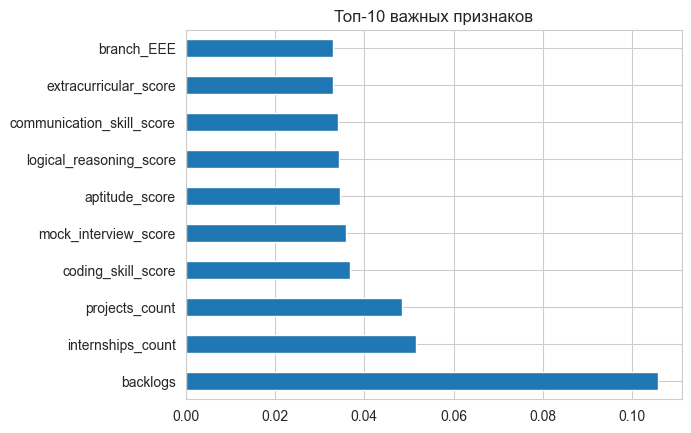

In [104]:
import matplotlib.pyplot as plt

# Достаем названия колонок после OneHotEncoding
ohe_cols = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out()
all_features = numeric_features + list(ohe_cols)

importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Топ-10 важных признаков")
plt.show()

In [105]:
# --- НОВЫЙ FEATURE ENGINEERING ---

# 1. Создаем общий балл компетенций
df['total_score'] = df['coding_skill_score'] + df['soft_skill_score'] + df['aptitude_test_score']

# 2. Относительная успеваемость (насколько баллы выше/ниже среднего по выборке)
df['score_vs_average'] = df['total_score'] / df['total_score'].mean()

# 3. Бинарный признак "Топ-студент" (высокий CGPA + высокая активность)
df['is_high_performer'] = ((df['cgpa'] > 8) & (df['extracurricular_activities'] == 'Yes')).astype(int)

# 4. Удаляем мусор
X = df.drop(columns=['student_id', 'salary_package_lpa', 'placement_status'])
y = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

# Обновляем списки колонок
numeric_features = ['cgpa', 'coding_skill_score', 'soft_skill_score',
                    'aptitude_test_score', 'projects_completed',
                    'total_score', 'score_vs_average']
categorical_features = ['gender', 'college_tier', 'volunteer_experience', 'is_high_performer']

# --- ДАЛЕЕ ИСПОЛЬЗУЙ XGBOOST С ЭТИМИ ПАРАМЕТРАМИ ---
from xgboost import XGBClassifier

final_xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01, # Маленький шаг, чтобы не проскочить минимум
    max_depth=4,        # Уменьшаем глубину, чтобы не учить шум
    gamma=1,            # Добавляем жесткую регуляризацию
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric='logloss'
)

KeyError: 'soft_skill_score'

In [64]:
# Убираем лишние пробелы и приводим к нижнему регистру
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Загрузка
df = pd.read_csv("data/student_placement_prediction_dataset_2026.csv")

# 2. FEATURE ENGINEERING (с правильными именами колонок)
# Общий балл по тестам
df['total_score'] = (df['coding_skill_score'] +
                     df['aptitude_score'] +
                     df['communication_skill_score'] +
                     df['logical_reasoning_score'])

# Опыт и активность (суммируем достижения)
df['total_experience'] = (df['internships_count'] +
                          df['projects_count'] +
                          df['certifications_count'] +
                          df['hackathons_participated'])

# Флаг "Проблемный студент" (низкий балл или много долгов)
df['has_backlogs'] = (df['backlogs'] > 0).astype(int)

# 3. Разделение на X и y
# Удаляем таргет, ID и зарплату (утечка данных)
X = df.drop(columns=['student_id', 'salary_package_lpa', 'placement_status'])
y = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

# 4. Группировка признаков
numeric_features = [
    'age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count',
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'hackathons_participated', 'github_repos',
    'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
    'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours',
    'study_hours_per_day', 'total_score', 'total_experience'
]

categorical_features = ['gender', 'branch', 'college_tier', 'volunteer_experience']

# 5. Препроцессинг
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 6. Модель XGBoost (более стабильная)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# 7. Обучение и проверка
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Новая Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Новая Accuracy: 0.5615
              precision    recall  f1-score   support

           0       0.53      0.34      0.41      9108
           1       0.57      0.75      0.65     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.53     20000
weighted avg       0.55      0.56      0.54     20000



In [66]:
# Посмотрим на корреляцию всех признаков с целевой переменной
corr_matrix = df.select_dtypes(include=[np.number]).corr()
print("Корреляция с целевой переменной (топ-10):")
print(corr_matrix['placement_status'].abs().sort_values(ascending=False).head(10))

Корреляция с целевой переменной (топ-10):


KeyError: 'placement_status'